# Seaborn Foundations


```{contents}
:local:
:depth: 2
```


## Overview

Seaborn is a high-level visualization library built on top of Matplotlib. It gives you cleaner defaults and concise plotting functions for statistical graphics, while still letting you use Matplotlib for fine-grained control. Pandas plotting is excellent for fast, direct plotting from a `DataFrame`. Seaborn becomes stronger when you need **semantic mappings** (color/style/size by variables), cleaner statistical defaults, and grouped comparisons.

Practical rules:
- Start with Pandas for quick checks.
- Use **Seaborn** for **statistical/grouped** visuals.
- Drop to Matplotlib when you need exact low-level control.

As a comparison between the three visualization libraries:

In this notebook, we will use the following learning path:

1. Quick start (first useful plots)
2. Data model and semantic mappings (`hue`, `style`, `size`)
3. Core seaborn plot families (distribution, relational, categorical)
4. Figure-level wrappers and faceting (`displot`, `relplot`, `catplot`)
5. Multivariate views (`pairplot`, `jointplot`, `heatmap`)
6. Optional KDE internals appendix


By convention, Seaborn is imported as `sns`:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
# %pip install seaborn
import seaborn as sns

# Set consistent defaults for all following plots
sns.set_theme(style='whitegrid', context='notebook')

tips = sns.load_dataset('tips')
planets = sns.load_dataset('planets')
iris = sns.load_dataset('iris')
penguins = sns.load_dataset('penguins')

### Quick Comparison

#### Seaborn vs. Pandas

Compare the two plots in the next cells and you shall see that seaborn is giving more information about the data:

- `pd.plot.scatter()`: fast DataFrame-first plotting.
- `sns.scatterplot()`: semantic mappings (`hue`, `style`, `size`) with cleaner statistical **defaults**.

Style note: this plot uses the global theme set earlier with `sns.set_theme(style='whitegrid', context='notebook')`.

Both plots are placed side-by-side using `plt.subplots()`. The **`ax=` parameter** tells each plotting function which subplot panel to draw on — without it, every call would create its own separate figure.


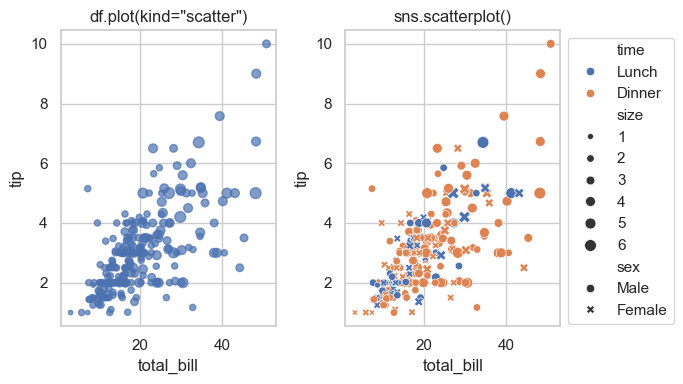

In [2]:
fig, ax = plt.subplots(1, 2, figsize=(7, 4))

# Pandas: fast DataFrame-first plotting
tips.plot(
    kind='scatter',
    x='total_bill', y='tip',
    s=tips['size']*10,          ### s, not size, for scatter plot marker size
    alpha=0.7,                  ### add some transparency for better visibility
    ax=ax[0],
    title='df.plot(kind="scatter")',
)
# Seaborn: more flexible, but requires more code
sns.scatterplot(
    data=tips,
    x='total_bill', y='tip',
    hue='time', 
    style='sex', 
    size='size',
    ax=ax[1]
)
ax[1].set_title('sns.scatterplot()')
ax[1].legend(bbox_to_anchor=(1, 1))  ### move legend outside the plot
plt.tight_layout()


### Comparing Libraries

Compare histogram APIs across pandas, Matplotlib, and seaborn:

- **pandas**: DataFrame-oriented convenience
- **Matplotlib**: lower-level direct control
- **seaborn**: statistical defaults and cleaner styling

   total_bill   tip
0       16.99  1.01
1       10.34  1.66
2       21.01  3.50
3       23.68  3.31
4       24.59  3.61


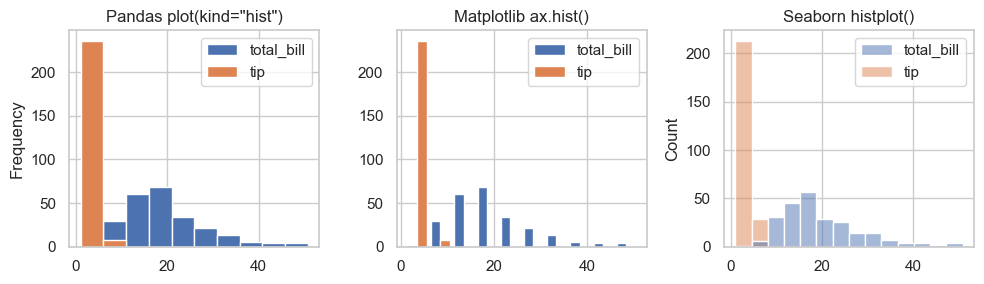

In [3]:
fig, ax = plt.subplots(1, 3, figsize=(10, 3))

data = tips[['total_bill', 'tip']]
print(data.head())

### Pandas histogram
data.plot(kind='hist', title='Pandas plot(kind="hist")', ax=ax[0])

### Matplotlib histogram
ax[1].hist(data, label=['total_bill', 'tip'])
ax[1].set_title('Matplotlib ax.hist()')
ax[1].legend()

### Seaborn histogram
sns.histplot(data=data, ax=ax[2])
ax[2].set_title('Seaborn histplot()')

plt.tight_layout()


The histograms are different because:
- Matplotlib and Pandas uses 10 bins by default; whereas Seaborn uses uses an automatic bin-width algorithm (Sturges or FD rule), which may produce more or fewer bins depending on the data distribution.
- Matplotlib has relatively narrow bin width because we are passing a 2-column DataFrame directly to `ax.hist()`, and Matplotlib is plotting each column as a separate histogram side-by-side each within half of the bin-width.
- The Seaborn plot has an default alpha (transparency) when the plots overlap.

The rule of thumb for choosing among the libraries: if you want a fast exploratory plot, Seaborn is more automatic; if you need precise control over bins, colors, and layout, Matplotlib gives you more flexibility.

### Plotting Methods Example

Let's start with a few axes-level examples. This gives you a fast way to recognize seaborn syntax before diving into API details. Here we see three different plotting functions of seaborn: `histplot()`, `scatterplot()`, and `boxplot()`. 


Let's take a look at the `tips` dataset.

In [4]:
# df.loc[row_label, column_label]

tips.loc[:, ['total_bill', 'tip', 'size', 'day', 'time', 'sex']].head()

,total_bill,tip,size,day,time,sex
0,16.99,1.01,2,Sun,Dinner,Female
1,10.34,1.66,3,Sun,Dinner,Male
2,21.01,3.50,3,Sun,Dinner,Male
3,23.68,3.31,2,Sun,Dinner,Male
4,24.59,3.61,4,Sun,Dinner,Female


Using the MPL `subplots()` function, you can place the plots side-by-side. You can see that the seaborn syntax for calling the plotting functions is familiar but the method names are different. Here we have one plot created by MPL and three by seaborn. 

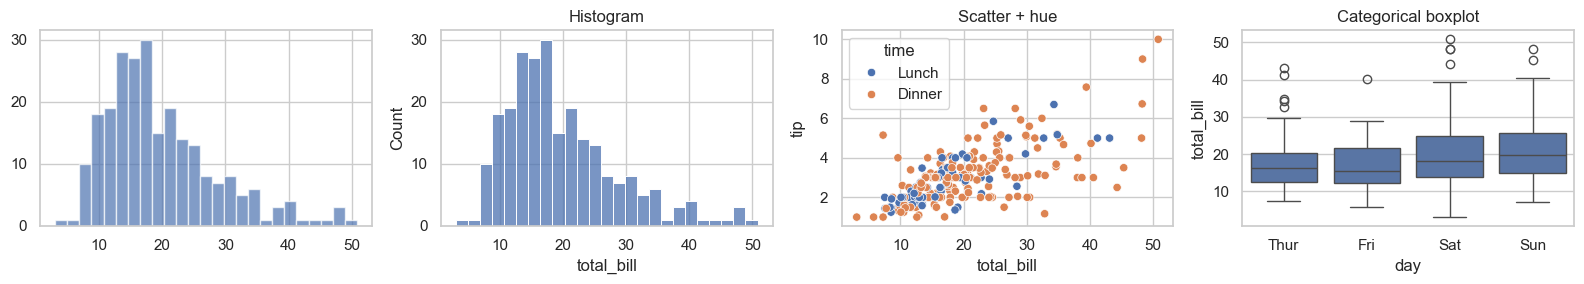

In [5]:
fig, ax = plt.subplots(1, 4, figsize=(16, 3))

### Matplotlib
ax[0].hist(tips['total_bill'], bins=25, alpha=0.7)

### Seaborn
sns.histplot(data=tips, x='total_bill', bins=25, ax=ax[1])
ax[1].set_title('Histogram')

### Seaborn with hue
sns.scatterplot(data=tips, x='total_bill', y='tip', hue='time', ax=ax[2])
ax[2].set_title('Scatter + hue')

### Seaborn categorical plot
sns.boxplot(data=tips, x='day', y='total_bill', ax=ax[3])
ax[3].set_title('Categorical boxplot')

plt.tight_layout()


## Seaborn Data Model and Semantic Mappings

Seaborn works best with **tidy (long-form) data**:
- each column is a variable
- each row is one observation

Common semantic mappings:
- `hue`: map category/value to color
- `style`: map category to marker or line style
- `size`: map numeric values to marker size

Important distinction:
- Use `size=...` to map from data
- Use `s=...` for a constant marker size


### Data Formats

Data can be structured in different ways. Understanding these formats is essential because most Python visualization and analysis libraries, including Seaborn and pandas, expect data in a specific format. The common data formats are tidy, wide, and nested. 

| Format | Best For |
|--------|----------|
| Tidy | Seaborn, statsmodels, most analysis |
| Wide | Excel, quick inspection, some ML models |
| Nested | Raw API/JSON data before processing |

In practice, data often arrives in wide or nested format and should be converted to tidy before visualization or analysis. For example, `sns.barplot(data=df, x='category', y='value')` assumes each row is one observation. If your DataFrame is wide (one column per category), Seaborn won't work as expected and students will get confusing errors. So the practical point is: if a Seaborn plot looks wrong or throws an error, check whether your DataFrame is in tidy format first — and if not, use `pd.melt()` to reshape it.

### Tidy (Long) Format

In tidy data, 

- **each row is one observation**, 
- **each column is one variable**, and 
- **each cell holds one value**. 
 
This is the preferred format for analysis and visualization.

In [6]:
import pandas as pd

tidy = pd.DataFrame({
    'student': ['Alice', 'Alice', 'Bob', 'Bob'],
    'subject': ['math', 'english', 'math', 'english'],
    'score':   [90, 85, 78, 88]
})
tidy

,student,subject,score
0,Alice,math,90
1,Alice,english,85
2,Bob,math,78
3,Bob,english,88


### Wide Format

In wide data, 

- each row represents one subject, and 
- variables are spread across multiple columns. 
 
This format is easier for humans to read at a glance.

In [7]:
wide = pd.DataFrame({
    'student': ['Alice', 'Bob'],
    'math':    [90, 78],
    'english': [85, 88]
})
wide

,student,math,english
0,Alice,90,85
1,Bob,78,88


### Nested Format

Nested data stores values inside **dictionaries** or **lists**, common when loading from JSON or APIs. It must be flattened before use.

In [8]:
nested = {
    'Alice': {'math': 90, 'english': 85},
    'Bob':   {'math': 78, 'english': 88}
}
nested

{'Alice': {'math': 90, 'english': 85}, 'Bob': {'math': 78, 'english': 88}}

### Converting Formats

**Wide vs. tidy data errors:**
If you see `KeyError: 'column_name'`, check if your DataFrame is in tidy format. Use `pd.melt()` to convert wide to tidy.

In [9]:
students = pd.DataFrame({
    'student': ['Alice', 'Bob', 'Carol', 'David', 'Eve'],
    'gender':  ['F', 'M', 'F', 'M', 'F'],
    'grade':   [10, 10, 11, 11, 12],
    'math':    [90, 78, 85, 72, 95],
    'english': [85, 88, 80, 76, 92],
    'science': [92, 80, 88, 70, 96]
})
print("Wide DataFrame:")
print(students, "\n")

# Wide --> Tidy
tidy = pd.melt(students, 
               id_vars=['student', 'gender', 'grade'],
               var_name='subject', 
               value_name='score')
print("Tidy DataFrame:")
print(tidy)

# Tidy --> Wide
wide = tidy.pivot(index='student',
                  columns='subject', values='score')

# Nested --> Tidy
# Cleaner Nested --> Tidy conversion
flat = pd.DataFrame(nested).T.reset_index()
flat.columns = ['student'] + list(flat.columns[1:])
flat = pd.melt(flat, id_vars='student',
               var_name='subject', value_name='score')

Wide DataFrame:
  student gender  grade  math  english  science
0   Alice      F     10    90       85       92
1     Bob      M     10    78       88       80
2   Carol      F     11    85       80       88
3   David      M     11    72       76       70
4     Eve      F     12    95       92       96 

Tidy DataFrame:
   student gender  grade  subject  score
0    Alice      F     10     math     90
1      Bob      M     10     math     78
2    Carol      F     11     math     85
3    David      M     11     math     72
4      Eve      F     12     math     95
5    Alice      F     10  english     85
6      Bob      M     10  english     88
7    Carol      F     11  english     80
8    David      M     11  english     76
9      Eve      F     12  english     92
10   Alice      F     10  science     92
11     Bob      M     10  science     80
12   Carol      F     11  science     88
13   David      M     11  science     70
14     Eve      F     12  science     96


## Figure vs. Axes-Level APIs

Seaborn has two common usage patterns:

- **Figure-level** functions (e.g., `displot`, `relplot`, `catplot`) manage an entire figure/grid and return grid objects (`FacetGrid`, `JointGrid`, `PairGrid`).
- **Axes-level** functions (e.g., `histplot`, `scatterplot`, `lineplot`, `boxplot`) draw on a specific Matplotlib `ax` and return an `Axes`. In other words, axes-level functions make self-contained plots.

Rule of thumb:
- Use figure-level when **faceting** is the main goal.
- Use axes-level for **custom** subplot composition.


<!-- <figure>
    <img src="../../figures/sns_plot_chart.png" alt="Seaborn Plots Chart" width=400 >
    <figcaption><a src="https://seaborn.pydata.org/tutorial/function_overview.html">Seaborn Plots Chart</a></figcaption>
<figure> -->
```{figure} ../../figures/sns_plot_chart.png 
:name: sns_plot_chart
:width: 375
:align: center
:alt: Seaborn Plots Chart
Seaborn Plots [Chart](https://seaborn.pydata.org/tutorial/function_overview.html)
``` 

The syntax for using seaborn is:

```text
sns.PLOT-TYPE(data=df, x='col_a', y='col_b', hue='col_c')
      ↑           ↑         ↑          ↑          ↑
   plot type   DataFrame  x-axis     y-axis     color by
```

The table below summarizes common figure-level functions and their typical axes-level backends.

### API Differences
| Aspect | Figure-level | Axes-level |
|---|---|---|
| **Returns** | `FacetGrid` · `JointGrid` · `PairGrid` | `Axes` |
| **Faceting** | Built-in via `row=`, `col=`, `col_wrap=` | Not available — use `plt.subplots()` + loop |
| **Sizing** | `height=` + `aspect=` | `plt.subplots(figsize=(w, h))` |
| **Multiple panels** | **Automatic grid** from data | `fig, axes = plt.subplots()` + pass `ax=` |
| **Layering plots** | ✗ Hard | ✓ Easy — multiple functions on same `ax` |
| **When to use** | Grouped/faceted views, small multiples | Custom layouts, overlaying, single-axes control |

### Function Reference

| Figure-level | Axes-level Functions | Typical use |
|---|---|---|
| `displot()` | `histplot()`, `kdeplot()`, `ecdfplot()` | Distributions, histograms, KDE, ECDF |
| `relplot()` | `scatterplot()`, `lineplot()` | Relationships and trends |
| `catplot()` | `stripplot()`, `swarmplot()`, `boxplot()`, `violinplot()`, `boxenplot()`, `barplot()`, `countplot()`, `pointplot()` | Categorical comparisons |
| `jointplot()` | `scatterplot()`, `kdeplot()`, `histplot()`, `regplot()`, `residplot()`, `kind="hex"` *(Matplotlib hexbin)* | Bivariate plots with marginals and/or regression |
| `pairplot()` | `scatterplot()`, `kdeplot()`, `histplot()` | Pairwise relationships across variables |


## Section Practice

Use this short exercise to check the main workflow from this section.


In [10]:
### Exercise: Plan a Seaborn Foundations Chart
# A team wants to compare sales across four regions.
# Create two lists named regions and sales. Then print the region with the highest sales.
### Your code starts here




### Your code ends here


In [11]:
### Solution
regions = ["North", "South", "East", "West"]
sales = [240, 215, 260, 230]
best_index = sales.index(max(sales))
print(regions[best_index])


East
